<a href="https://colab.research.google.com/github/Tazin17/pain-intensity-prediction-from-laser-evoked-eeg-responses/blob/main/v3_pipeline_of_exp8_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

drive.mount('/content/drive')

# LOAD SAVED FEATURES

X_epochs = np.load(
    os.path.join(
        OUT_DIR,
        "X_epochs.npy"
    )
)


epoch_labels = np.load(
    os.path.join(
        OUT_DIR,
        "epoch_labels.npy"
    )
)


epoch_subjects = np.load(
    os.path.join(
        OUT_DIR,
        "epoch_subjects.npy"
    )
)


X_norm = np.load(
    os.path.join(
        OUT_DIR,
        "X_norm.npy"
    )
)


X_pain = np.load(
    os.path.join(
        OUT_DIR,
        "X_pain.npy"
    )
)


X_hand_norm = np.load(
    os.path.join(
        OUT_DIR,
        "X_hand_norm.npy"
    )
)


X_riem = np.load(
    os.path.join(
        OUT_DIR,
        "X_riem.npy"
    )
)


print("All data loaded")
print(X_epochs.shape)
print(X_hand_norm.shape)
print(X_riem.shape)


In [ ]:
import os
from google.colab import drive

# Try to unmount if it's already mounted or partially mounted
try:
  drive.flush_and_unmount()
  print('Drive unmounted.')
except ValueError:
  pass # Drive was not mounted, nothing to unmount

# Ensure the mount point is clean
if os.path.isdir('/content/drive'):
  # Remove all contents of the directory, but not the directory itself
  # This avoids issues if the directory is still seen as a mount point
  for item in os.listdir('/content/drive'):
    item_path = os.path.join('/content/drive', item)
    if os.path.isfile(item_path):
      os.remove(item_path)
    elif os.path.isdir(item_path):
      import shutil
      shutil.rmtree(item_path)
  print('Cleared /content/drive directory.')
else:
  # If the directory doesn't exist, create it
  os.makedirs('/content/drive', exist_ok=True)
  print('Created /content/drive directory.')

# Attempt to mount again
drive.mount('/content/drive', force_remount=True)

Drive unmounted.
Created /content/drive directory.
Mounted at /content/drive


In [ ]:
!pip -q install pymatreader mne scipy scikit-learn pandas numpy matplotlib tqdm

In [ ]:
# CELL 2 — Imports and paths

import os, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from pymatreader import read_mat
from scipy.signal import welch
from scipy.stats import skew, kurtosis

EXP_NAME = "EXP8"

# Change this path if your Exp8 folder name is different
EXP8_ROOT = "/content/drive/MyDrive/my dataset_raw_main_exp8"

OUT_DIR = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH"
os.makedirs(OUT_DIR, exist_ok=True)

print("EXP8_ROOT exists:", os.path.exists(EXP8_ROOT))
print("OUT_DIR:", OUT_DIR)

EXP8_ROOT exists: True
OUT_DIR: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH


In [ ]:
# CELL 3 — Find Exp8 rerefer .set files

candidate_dirs = [
    "/content/exp8_rerefer",
    os.path.join(EXP8_ROOT, "derivatives", "rerefer"),
    os.path.join(EXP8_ROOT, "derivatives-rerefer"),
    os.path.join(EXP8_ROOT, "rerefer"),
]

REREFER_DIR = None
set_files = []

for d in candidate_dirs:
    files = sorted(glob.glob(os.path.join(d, "*.set")))
    if len(files) > 0:
        REREFER_DIR = d
        set_files = files
        break

if len(set_files) == 0 and os.path.exists(EXP8_ROOT):
    all_set_files = sorted(glob.glob(os.path.join(EXP8_ROOT, "**", "*.set"), recursive=True))
    rerefer_files = [f for f in all_set_files if "rerefer" in f.lower()]
    set_files = sorted(rerefer_files if len(rerefer_files) > 0 else all_set_files)
    if len(set_files) > 0:
        REREFER_DIR = os.path.dirname(set_files[0])

print("REREFER_DIR:", REREFER_DIR)
print("Number of .set files:", len(set_files))

if len(set_files) == 0:
    raise FileNotFoundError("No Exp8 .set files found. Check EXP8_ROOT.")

print("First 5 files:")
for f in set_files[:5]:
    print(f)

REREFER_DIR: /content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer
Number of .set files: 223
First 5 files:
/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-001_223ByBP.set
/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-002_223ByBP.set
/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-003_223ByBP.set
/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-004_223ByBP.set
/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-005_223ByBP.set


In [ ]:
# CELL 4 — Helper functions

def safe_scalar(x):
    if isinstance(x, np.ndarray):
        if x.size == 0:
            return np.nan
        return safe_scalar(x.flatten()[0])
    if isinstance(x, list):
        if len(x) == 0:
            return np.nan
        return safe_scalar(x[0])
    return x

def get_subject_id(path):
    return os.path.basename(path).split("_")[0]

def clean_channel_name(ch):
    return str(ch).replace(" ", "").replace("-", "").replace(".", "").replace("'", "").replace('"', "")

def get_channel_labels(chanlocs, nbchan=None):
    labels = []

    if isinstance(chanlocs, dict) and "labels" in chanlocs:
        labels = [str(x) for x in chanlocs["labels"]]

    elif isinstance(chanlocs, list):
        for ch in chanlocs:
            if isinstance(ch, dict) and "labels" in ch:
                labels.append(str(safe_scalar(ch["labels"])))

    labels = [clean_channel_name(x) for x in labels if str(x).strip() != ""]

    if nbchan is not None and len(labels) != nbchan:
        labels = [f"Ch{i+1:03d}" for i in range(nbchan)]

    return labels

def listify(x):
    if isinstance(x, list):
        return x
    if isinstance(x, np.ndarray):
        return list(x.flatten())
    return [x]

def get_times_ms(mat):
    if "times" in mat:
        times = np.array(mat["times"], dtype=float).flatten()
        if np.nanmax(np.abs(times)) < 20:
            times = times * 1000
        return times

    pnts = int(safe_scalar(mat["pnts"]))
    xmin = float(safe_scalar(mat.get("xmin", -1)))
    xmax = float(safe_scalar(mat.get("xmax", 2)))
    return np.linspace(xmin * 1000, xmax * 1000, pnts)

def load_eeg_data_from_set(mat, set_path, rerefer_dir):
    data = mat["data"]

    if isinstance(data, str):
        datfile = str(safe_scalar(mat.get("datfile", "")))

        if datfile == "" or datfile.lower() == "nan":
            datfile = os.path.splitext(os.path.basename(set_path))[0] + ".fdt"

        fdt_path = os.path.join(rerefer_dir, datfile)

        if not os.path.exists(fdt_path):
            fdt_path = os.path.join(os.path.dirname(set_path), datfile)

        if not os.path.exists(fdt_path):
            raise FileNotFoundError(f"Missing .fdt file: {fdt_path}")

        nbchan = int(safe_scalar(mat["nbchan"]))
        pnts = int(safe_scalar(mat["pnts"]))
        trials = int(safe_scalar(mat["trials"]))

        raw = np.fromfile(fdt_path, dtype=np.float32)
        data = raw.reshape((nbchan, pnts, trials), order="F")

    else:
        data = np.array(data)

    if data.ndim == 2:
        nbchan = int(safe_scalar(mat["nbchan"]))
        pnts = int(safe_scalar(mat["pnts"]))
        trials = int(safe_scalar(mat["trials"]))
        data = data.reshape((nbchan, pnts, trials), order="F")

    return data

def extract_trial_metadata_from_epoch(mat, n_trials):
    pain = [np.nan] * n_trials
    laser = [np.nan] * n_trials
    etype = [np.nan] * n_trials

    epoch = mat.get("epoch", None)

    pain_keys = ["eventrating", "rating", "painrating", "eventpainrating", "eventNRS", "NRS"]
    laser_keys = ["eventlaser_power", "laser_power", "laserpower", "eventlaserpower", "eventLaserPower"]
    type_keys = ["eventtype", "type"]

    if isinstance(epoch, list):
        for i in range(min(len(epoch), n_trials)):
            ep = epoch[i]
            if isinstance(ep, dict):
                for key in pain_keys:
                    if key in ep:
                        pain[i] = safe_scalar(ep[key])
                        break
                for key in laser_keys:
                    if key in ep:
                        laser[i] = safe_scalar(ep[key])
                        break
                for key in type_keys:
                    if key in ep:
                        etype[i] = safe_scalar(ep[key])
                        break

    elif isinstance(epoch, dict):
        for key in pain_keys:
            if key in epoch:
                vals = listify(epoch[key])
                for i in range(min(len(vals), n_trials)):
                    pain[i] = safe_scalar(vals[i])
                break

        for key in laser_keys:
            if key in epoch:
                vals = listify(epoch[key])
                for i in range(min(len(vals), n_trials)):
                    laser[i] = safe_scalar(vals[i])
                break

        for key in type_keys:
            if key in epoch:
                vals = listify(epoch[key])
                for i in range(min(len(vals), n_trials)):
                    etype[i] = safe_scalar(vals[i])
                break

    return pain, laser, etype

In [ ]:
# CELL 5 — Inspect all .set files: subjects, channels, epochs

inventory_rows = []
failed_rows = []

for set_path in tqdm(set_files, desc="Inspecting .set files"):
    sid = get_subject_id(set_path)

    try:
        mat = read_mat(set_path)

        inventory_rows.append({
            "subject_id": sid,
            "file": os.path.basename(set_path),
            "nbchan": int(safe_scalar(mat.get("nbchan", np.nan))),
            "pnts": int(safe_scalar(mat.get("pnts", np.nan))),
            "trials_epochs": int(safe_scalar(mat.get("trials", np.nan))),
            "srate": float(safe_scalar(mat.get("srate", np.nan))),
            "xmin_sec": float(safe_scalar(mat.get("xmin", np.nan))),
            "xmax_sec": float(safe_scalar(mat.get("xmax", np.nan))),
        })

    except Exception as e:
        failed_rows.append({
            "subject_id": sid,
            "file": os.path.basename(set_path),
            "error": str(e)
        })

inventory_df = pd.DataFrame(inventory_rows)
failed_df = pd.DataFrame(failed_rows)

inventory_path = os.path.join(OUT_DIR, "exp8_inventory_epoch_counts.csv")
failed_path = os.path.join(OUT_DIR, "exp8_inventory_failed_files.csv")

inventory_df.to_csv(inventory_path, index=False)
failed_df.to_csv(failed_path, index=False)

print("Subjects/files inspected:", len(inventory_df))
print("Failed files:", len(failed_df))

print("\nTrial/epoch count distribution:")
display(inventory_df["trials_epochs"].value_counts().sort_index())

print("\nTotal retained epochs after preprocessing:")
print(int(inventory_df["trials_epochs"].sum()))

print("\nTheoretical maximum:")
print("223 subjects × 30 trials = 6690 epochs")

display(inventory_df.head())

Inspecting .set files: 100%|██████████| 223/223 [01:18<00:00,  2.84it/s]


Subjects/files inspected: 223
Failed files: 0

Trial/epoch count distribution:


,count
trials_epochs,
19,2
20,1
21,3
22,1
23,5
24,9
25,12
26,15
27,16



Total retained epochs after preprocessing:
6275

Theoretical maximum:
223 subjects × 30 trials = 6690 epochs


,subject_id,file,nbchan,pnts,trials_epochs,srate,xmin_sec,xmax_sec
0,sub-001,sub-001_223ByBP.set,64,3000,28,1000.0,-1.0,1.999
1,sub-002,sub-002_223ByBP.set,64,3000,25,1000.0,-1.0,1.999
2,sub-003,sub-003_223ByBP.set,62,3000,25,1000.0,-1.0,1.999
3,sub-004,sub-004_223ByBP.set,64,3000,27,1000.0,-1.0,1.999
4,sub-005,sub-005_223ByBP.set,64,3000,27,1000.0,-1.0,1.999


In [ ]:
# CELL 6 — Inspect one subject deeply

example_path = set_files[0]
mat = read_mat(example_path)

print("Example file:", example_path)

print("\nBasic shape info:")
for k in ["nbchan", "pnts", "trials", "srate", "xmin", "xmax"]:
    print(k, ":", safe_scalar(mat.get(k, None)))

nbchan = int(safe_scalar(mat["nbchan"]))
labels = get_channel_labels(mat.get("chanlocs", []), nbchan=nbchan)

print("\nNumber of channel labels:", len(labels))
print("First 30 channel labels:")
print(labels[:30])

print("\nEpoch object type:", type(mat.get("epoch", None)))

epoch = mat.get("epoch", None)

if isinstance(epoch, list) and len(epoch) > 0:
    print("\nFirst epoch keys:")
    print(epoch[0].keys() if isinstance(epoch[0], dict) else type(epoch[0]))

elif isinstance(epoch, dict):
    print("\nEpoch dictionary keys:")
    print(epoch.keys())

Example file: /content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-001_223ByBP.set

Basic shape info:
nbchan : 64
pnts : 3000
trials : 28
srate : 1000
xmin : -1
xmax : 1.999

Number of channel labels: 64
First 30 channel labels:
['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz', 'Oz', 'FC1', 'FC2', 'CP1', 'CP2', 'FC5', 'FC6', 'CP5', 'CP6', 'FT9', 'FT10']

Epoch object type: <class 'dict'>

Epoch dictionary keys:
dict_keys(['event', 'eventlatency', 'eventduration', 'eventchannel', 'eventbvtime', 'eventbvmknum', 'eventvisible', 'eventtype', 'eventcode', 'eventurevent', 'eventrating', 'eventlaser_power'])


In [ ]:
# CELL 7 — Extract trial metadata and binary labels

metadata_rows = []
failed_rows = []

for set_path in tqdm(set_files, desc="Extracting metadata"):
    sid = get_subject_id(set_path)

    try:
        mat = read_mat(set_path)
        n_trials = int(safe_scalar(mat["trials"]))

        pain, laser, etype = extract_trial_metadata_from_epoch(mat, n_trials)

        for t in range(n_trials):
            metadata_rows.append({
                "experiment": EXP_NAME,
                "subject_id": sid,
                "trial_num": t + 1,
                "painrating": pain[t],
                "laser_power": laser[t],
                "event_type": etype[t],
                "source_file": os.path.basename(set_path)
            })

    except Exception as e:
        failed_rows.append({
            "subject_id": sid,
            "file": os.path.basename(set_path),
            "error": str(e)
        })

meta_df = pd.DataFrame(metadata_rows)
failed_meta_df = pd.DataFrame(failed_rows)

meta_df["painrating"] = pd.to_numeric(meta_df["painrating"], errors="coerce")
meta_df["laser_power"] = pd.to_numeric(meta_df["laser_power"], errors="coerce")

# Final binary label:
# NRS 0–4 = low pain, NRS 5–10 = high pain
meta_df["pain_label"] = np.where(meta_df["painrating"] >= 5, 1, 0)
meta_df["pain_class"] = np.where(meta_df["pain_label"] == 1, "high_pain", "low_pain")

meta_path = os.path.join(OUT_DIR, "exp8_trial_metadata_with_binary_labels.csv")
failed_meta_path = os.path.join(OUT_DIR, "exp8_metadata_failed_files.csv")

meta_df.to_csv(meta_path, index=False)
failed_meta_df.to_csv(failed_meta_path, index=False)

print("Metadata shape:", meta_df.shape)
print("Subjects:", meta_df["subject_id"].nunique())
print("Total epochs/trials:", len(meta_df))
print("Missing painrating:", meta_df["painrating"].isna().sum())
print("Missing laser_power:", meta_df["laser_power"].isna().sum())

print("\nPain rating distribution:")
display(meta_df["painrating"].value_counts(dropna=False).sort_index())

print("\nBinary class distribution:")
display(meta_df["pain_class"].value_counts(dropna=False))

print("\nSaved:", meta_path)

Extracting metadata: 100%|██████████| 223/223 [00:16<00:00, 13.68it/s]


Metadata shape: (6275, 9)
Subjects: 223
Total epochs/trials: 6275
Missing painrating: 0
Missing laser_power: 0

Pain rating distribution:


,count
painrating,
0,51
1,207
2,438
3,855
4,1174
5,1012
6,808
7,751
8,502



Binary class distribution:


,count
pain_class,
high_pain,3550
low_pain,2725



Saved: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/exp8_trial_metadata_with_binary_labels.csv


In [ ]:
# CELL 8 — Subject-wise label balance

subject_label_summary = meta_df.groupby("subject_id").agg(
    n_trials=("painrating", "count"),
    pain_min=("painrating", "min"),
    pain_max=("painrating", "max"),
    pain_mean=("painrating", "mean"),
    low_count=("pain_label", lambda x: int((x == 0).sum())),
    high_count=("pain_label", lambda x: int((x == 1).sum())),
).reset_index()

subject_label_summary["has_both_classes"] = (
    (subject_label_summary["low_count"] > 0) &
    (subject_label_summary["high_count"] > 0)
)

summary_path = os.path.join(OUT_DIR, "exp8_subject_label_balance.csv")
subject_label_summary.to_csv(summary_path, index=False)

print("Total subjects:", subject_label_summary.shape[0])
print("Subjects with both classes:", subject_label_summary["has_both_classes"].sum())
print("Subjects with only one class:", (~subject_label_summary["has_both_classes"]).sum())

print("\nTrial count distribution:")
display(subject_label_summary["n_trials"].value_counts().sort_index())

display(subject_label_summary.head(20))

Total subjects: 223
Subjects with both classes: 205
Subjects with only one class: 18

Trial count distribution:


,count
n_trials,
19,2
20,1
21,3
22,1
23,5
24,9
25,12
26,15
27,16


,subject_id,n_trials,pain_min,pain_max,pain_mean,low_count,high_count,has_both_classes
0,sub-001,28,0,7,4.571429,11,17,True
1,sub-002,25,0,6,1.960000,23,2,True
2,sub-003,25,1,9,3.640000,18,7,True
3,sub-004,27,2,8,5.518519,6,21,True
4,sub-005,27,3,6,4.518519,13,14,True
5,sub-006,30,2,6,3.866667,22,8,True
6,sub-007,28,0,7,4.714286,10,18,True
7,sub-008,30,1,6,3.266667,24,6,True
8,sub-009,27,1,6,3.074074,24,3,True
9,sub-010,26,4,9,6.384615,3,23,True


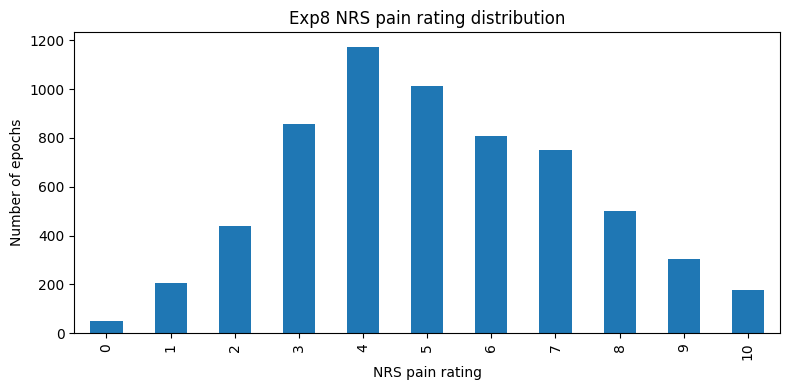

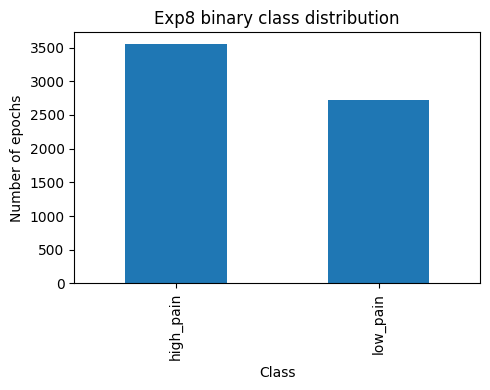

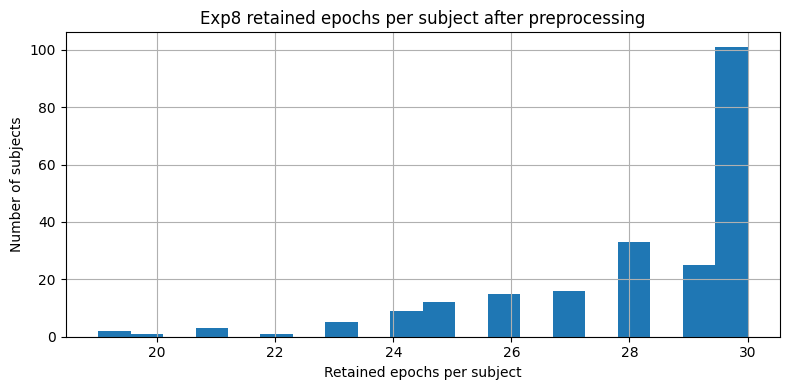

In [ ]:
# CELL 9 — Plot distributions

plt.figure(figsize=(8, 4))
meta_df["painrating"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("NRS pain rating")
plt.ylabel("Number of epochs")
plt.title("Exp8 NRS pain rating distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
meta_df["pain_class"].value_counts().plot(kind="bar")
plt.xlabel("Class")
plt.ylabel("Number of epochs")
plt.title("Exp8 binary class distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
subject_label_summary["n_trials"].hist(bins=20)
plt.xlabel("Retained epochs per subject")
plt.ylabel("Number of subjects")
plt.title("Exp8 retained epochs per subject after preprocessing")
plt.tight_layout()
plt.show()

In [ ]:
# CELL 10 — Feature extraction functions

def mean_window(sig, times, a, b):
    idx = np.where((times >= a) & (times <= b))[0]
    if len(idx) == 0:
        return np.nan
    return float(np.nanmean(sig[idx]))

def peak_amp_lat(sig, times, a, b, mode="min"):
    idx = np.where((times >= a) & (times <= b))[0]
    if len(idx) == 0:
        return np.nan, np.nan

    y = sig[idx]
    if np.all(np.isnan(y)):
        return np.nan, np.nan

    k = np.nanargmin(y) if mode == "min" else np.nanargmax(y)
    return float(y[k]), float(times[idx[k]])

def bandpower(sig, fs, fmin, fmax):
    if np.all(np.isnan(sig)):
        return np.nan

    freqs, psd = welch(sig, fs=fs, nperseg=min(512, len(sig)))
    idx = np.where((freqs >= fmin) & (freqs <= fmax))[0]

    if len(idx) == 0:
        return np.nan

    return float(np.trapz(psd[idx], freqs[idx]))

def hjorth_params(sig):
    sig = np.asarray(sig, dtype=float)

    if np.all(np.isnan(sig)):
        return np.nan, np.nan, np.nan

    sig = np.nan_to_num(sig, nan=np.nanmean(sig))

    diff1 = np.diff(sig)
    diff2 = np.diff(diff1)

    var0 = np.var(sig)
    var1 = np.var(diff1)
    var2 = np.var(diff2)

    activity = var0
    mobility = np.sqrt(var1 / var0) if var0 > 0 else np.nan
    complexity = np.sqrt(var2 / var1) / mobility if var1 > 0 and mobility > 0 else np.nan

    return float(activity), float(mobility), float(complexity)

def simple_entropy(sig, bins=20):
    sig = np.asarray(sig, dtype=float)
    sig = sig[~np.isnan(sig)]

    if len(sig) == 0:
        return np.nan

    hist, _ = np.histogram(sig, bins=bins, density=True)
    hist = hist[hist > 0]

    return float(-np.sum(hist * np.log(hist)))

In [ ]:
# CELL 11 — Load EEG epochs using LEP channel matching


PAIN_CHANNELS = [
    "Cz",
    "CPz",
    "Pz",
    "Fz",
    "CP1",
    "CP2",
    "C1",
    "C2",
    "FC1",
    "FC2"
]


X_list = []
epoch_subjects = []
epoch_labels = []
epoch_metadata = []

skipped_subjects = []



for set_path in tqdm(set_files, desc="Loading EEG epochs"):

    sid = get_subject_id(set_path)

    try:

        mat = read_mat(set_path)

        data = load_eeg_data_from_set(
            mat,
            set_path,
            REREFER_DIR
        )


        nbchan = int(
            safe_scalar(mat["nbchan"])
        )

        n_trials = int(
            safe_scalar(mat["trials"])
        )


        labels = get_channel_labels(
            mat.get("chanlocs",[]),
            nbchan
        )


        labels = [
            clean_channel_name(ch)
            for ch in labels
        ]


        # Find only LEP channels

        ch_indices=[]

        missing=[]


        for ch in PAIN_CHANNELS:

            if ch in labels:

                ch_indices.append(
                    labels.index(ch)
                )

            else:

                missing.append(ch)



        # only skip if LEP channels unavailable

        if len(missing)>0:

            skipped_subjects.append(
                (
                    sid,
                    missing
                )
            )

            continue



        # extract only 10 channels

        data = data[
            ch_indices,
            :,
            :
        ]



        pain,laser,etype = extract_trial_metadata_from_epoch(
            mat,
            n_trials
        )



        for tr in range(n_trials):


            rating = safe_scalar(
                pain[tr]
            )


            if pd.isna(rating):
                continue


            rating=float(rating)



            X_list.append(
                data[:,:,tr].astype(np.float32)
            )


            epoch_subjects.append(
                sid
            )


            epoch_labels.append(
                1 if rating>=5 else 0
            )


            epoch_metadata.append(
                {
                    "subject":sid,
                    "trial":tr+1,
                    "pain":rating,
                    "laser":laser[tr]
                }
            )



    except Exception as e:

        skipped_subjects.append(
            (
                sid,
                str(e)
            )
        )



X_epochs=np.stack(
    X_list,
    axis=0
)


epoch_subjects=np.array(
    epoch_subjects
)


epoch_labels=np.array(
    epoch_labels
).astype(int)



epoch_metadata=pd.DataFrame(
    epoch_metadata
)



print("X_epochs:",X_epochs.shape)

print("Labels:",
      np.bincount(epoch_labels))

print("Subjects:",
      len(np.unique(epoch_subjects)))

print("Skipped:",
      len(skipped_subjects))

print(skipped_subjects)

Loading EEG epochs: 100%|██████████| 223/223 [07:15<00:00,  1.95s/it]


X_epochs: (6275, 10, 3000)
Labels: [2725 3550]
Subjects: 223
Skipped: 0
[]


In [ ]:
# SAVE EEG DATA WITH PATH DISPLAY

import os


save_files = {
    "X_epochs": "X_epochs.npy",
    "epoch_labels": "epoch_labels.npy",
    "epoch_subjects": "epoch_subjects.npy"
}


# Save files

np.save(
    os.path.join(OUT_DIR, save_files["X_epochs"]),
    X_epochs
)

np.save(
    os.path.join(OUT_DIR, save_files["epoch_labels"]),
    epoch_labels
)

np.save(
    os.path.join(OUT_DIR, save_files["epoch_subjects"]),
    epoch_subjects
)



print("EEG data saved successfully\n")


# Display saved locations

for name, filename in save_files.items():

    path = os.path.join(
        OUT_DIR,
        filename
    )

    size_mb = os.path.getsize(path) / (1024**2)

    print(f"{name}:")
    print(f"Path: {path}")
    print(f"Size: {size_mb:.2f} MB")
    print("-"*50)

EEG data saved successfully

X_epochs:
Path: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/X_epochs.npy
Size: 718.12 MB
--------------------------------------------------
epoch_labels:
Path: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/epoch_labels.npy
Size: 0.05 MB
--------------------------------------------------
epoch_subjects:
Path: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/epoch_subjects.npy
Size: 0.17 MB
--------------------------------------------------


In [ ]:
print("X_epochs dtype:", X_epochs.dtype)
print("X_epochs shape:", X_epochs.shape)

print("Minimum:", np.min(X_epochs))
print("Maximum:", np.max(X_epochs))

print("Unique subjects:", len(np.unique(epoch_subjects)))

print("Unique channel count after alignment:",
      X_epochs.shape[1])

NameError: name 'X_epochs' is not defined

In [ ]:
print("X_list exists:", "X_list" in globals())
print("Number of loaded epochs:", len(X_list) if "X_list" in globals() else None)

X_list exists: True
Number of loaded epochs: 6275


In [ ]:
# CELL 12 — Baseline z-normalization

baseline_samples = 1000
# -1000 ms to 0 ms


X_norm = np.zeros_like(
    X_epochs,
    dtype=np.float32
)


for i, epoch in tqdm(
    enumerate(X_epochs),
    total=len(X_epochs),
    desc="Baseline normalization"
):

    # epoch shape:
    # channels x time

    baseline = epoch[:, :baseline_samples]


    mean = np.mean(
        baseline,
        axis=1,
        keepdims=True
    )


    std = np.std(
        baseline,
        axis=1,
        keepdims=True
    )


    X_norm[i] = (
        epoch - mean
    ) / (std + 1e-8)



print("Original:")
print(X_epochs.shape)


print("Normalized:")
print(X_norm.shape)


print(
    "Mean after normalization:",
    np.mean(X_norm[:,:,0:1000])
)


print(
    "Std after normalization:",
    np.std(X_norm[:,:,0:1000])
)

Baseline normalization: 100%|██████████| 6275/6275 [00:01<00:00, 5177.29it/s]


Original:
(6275, 10, 3000)
Normalized:
(6275, 10, 3000)
Mean after normalization: -2.3149589e-10
Std after normalization: 0.9999998


In [ ]:
# SAVE BASELINE NORMALIZED EEG WITH PATH DISPLAY

import os


filename = "X_norm.npy"


# Save file

save_path = os.path.join(
    OUT_DIR,
    filename
)


np.save(
    save_path,
    X_norm
)



print("Normalized EEG saved successfully\n")


# Display saved location

size_mb = os.path.getsize(save_path) / (1024**2)


print("X_norm:")
print(f"Path: {save_path}")
print(f"Size: {size_mb:.2f} MB")
print("-"*50)

Normalized EEG saved successfully

X_norm:
Path: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/X_norm.npy
Size: 718.12 MB
--------------------------------------------------


In [ ]:
# CELL 13 — Extract post-stimulus pain response window

# Sampling rate = 1000 Hz
# Epoch:
# -1000 ms to +1999 ms
#
# Index:
# -1000 ms = 0
# 0 ms      = 1000
# +1000 ms = 2000


stim_start = 1000   # 0 ms
stim_end = 2000     # 1000 ms


X_pain = X_norm[:, :, stim_start:stim_end]


print("Pain window shape:")
print(X_pain.shape)


# Verify dimensions

n_trials, n_channels, n_samples = X_pain.shape


print("\nTrials:", n_trials)
print("Channels:", n_channels)
print("Samples:", n_samples)

print(
    "\nTime duration:",
    n_samples / 1000,
    "seconds"
)

Pain window shape:
(6275, 10, 1000)

Trials: 6275
Channels: 10
Samples: 1000

Time duration: 1.0 seconds


In [ ]:
# SAVE PAIN WINDOW EEG WITH PATH DISPLAY

import os


filename = "X_pain.npy"


# Save file

save_path = os.path.join(
    OUT_DIR,
    filename
)


np.save(
    save_path,
    X_pain
)



print("Pain window saved successfully\n")


# Display saved location

size_mb = os.path.getsize(save_path) / (1024**2)


print("X_pain:")
print(f"Path: {save_path}")
print(f"Size: {size_mb:.2f} MB")
print("-"*50)

Pain window saved successfully

X_pain:
Path: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/X_pain.npy
Size: 239.37 MB
--------------------------------------------------


In [ ]:
# CELL 14 — Extract same 230 handcrafted features from baseline-normalized EEG


WINDOWS = {

    "early_0_200": (0,200),

    "n2win_180_350": (180,350),

    "p2win_300_600": (300,600),

    "late_600_1000": (600,1000),

    "global_0_1000": (0,1000)

}


BANDS = {

    "delta":(1,4),
    "theta":(4,8),
    "alpha":(8,13),
    "beta":(13,30),
    "gamma":(30,70)

}


fs = 1000



def extract_v3_handcrafted(epoch):

    """
    Input:
        epoch = channels x samples

    Output:
        230 handcrafted LEP features
    """

    channel_features = []


    # ===============================
    # Channel-wise features
    # 10 channels × 22 features
    # ===============================

    for ch in range(epoch.shape[0]):


        sig = epoch[ch]


        ch_features = []


        # 5 temporal window mean features

        for a,b in WINDOWS.values():

            ch_features.append(
                np.mean(sig[a:b])
            )



        # N2 features

        n2_segment = sig[180:350]

        n2_amp = np.min(
            n2_segment
        )

        n2_lat = np.argmin(
            n2_segment
        ) + 180



        # P2 features

        p2_segment = sig[300:600]

        p2_amp = np.max(
            p2_segment
        )

        p2_lat = np.argmax(
            p2_segment
        ) + 300



        ch_features.extend(
            [
                n2_amp,
                n2_lat,
                p2_amp,
                p2_lat,
                p2_amp-n2_amp
            ]
        )



        # 5 frequency features

        for fmin,fmax in BANDS.values():

            ch_features.append(

                bandpower(
                    sig,
                    fs,
                    fmin,
                    fmax
                )

            )



        # Hjorth features

        act,mob,comp = hjorth_params(sig)


        ch_features.extend(
            [
                act,
                mob,
                comp
            ]
        )



        # Entropy

        ch_features.append(
            simple_entropy(sig)
        )



        # Statistics

        ch_features.extend(
            [
                np.std(sig),
                skew(sig),
                kurtosis(sig)
            ]
        )


        # check:
        # 5+5+5+3+1+3 = 22

        channel_features.extend(
            ch_features
        )



    # ===============================
    # Global features
    # 10 features
    # ===============================


    global_sig = np.mean(
        epoch,
        axis=0
    )


    global_features=[]


    # 5 global window means

    for a,b in WINDOWS.values():

        global_features.append(
            np.mean(global_sig[a:b])
        )



    # Global N2

    n2_segment = global_sig[180:350]

    n2_amp = np.min(
        n2_segment
    )

    n2_lat = np.argmin(
        n2_segment
    ) + 180



    # Global P2

    p2_segment = global_sig[300:600]

    p2_amp = np.max(
        p2_segment
    )

    p2_lat = np.argmax(
        p2_segment
    ) + 300



    global_features.extend(
        [
            n2_amp,
            n2_lat,
            p2_amp,
            p2_lat,
            p2_amp-n2_amp
        ]
    )


    # Total:
    #
    # Channel:
    # 10 × 22 = 220
    #
    # Global:
    # 10
    #
    # Total:
    # 230


    features = (
        channel_features +
        global_features
    )


    return np.array(features)



# Extract features from all trials

X_hand_norm = np.array(

    [
        extract_v3_handcrafted(ep)

        for ep in tqdm(
            X_pain,
            desc="Extracting normalized handcrafted features"
        )
    ]

)



print(
    "Normalized handcrafted shape:",
    X_hand_norm.shape
)

Extracting normalized handcrafted features: 100%|██████████| 6275/6275 [08:03<00:00, 12.97it/s]

Normalized handcrafted shape: (6275, 230)


In [ ]:
# SAVE HANDCRAFTED FEATURES WITH PATH DISPLAY

import os


filename = "X_hand_norm.npy"


# Save file

save_path = os.path.join(
    OUT_DIR,
    filename
)


np.save(
    save_path,
    X_hand_norm
)



print("Handcrafted features saved successfully\n")


# Display saved location

size_mb = os.path.getsize(save_path) / (1024**2)


print("X_hand_norm:")
print(f"Path: {save_path}")
print(f"Size: {size_mb:.2f} MB")
print("-"*50)

Handcrafted features saved successfully

X_hand_norm:
Path: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/X_hand_norm.npy
Size: 11.01 MB
--------------------------------------------------


In [ ]:
# Install Riemannian EEG package

!pip -q install pyriemann

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.6/153.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 3.2 MB/s eta 0:00:00


In [ ]:
# CELL 15 — Riemannian covariance feature extraction


from scipy.signal import butter, filtfilt

from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace



fs = 1000



FILTER_BANDS = {

    "delta": (1,4),

    "theta": (4,8),

    "alpha": (8,13),

    "beta": (13,30),

    "gamma": (30,70)

}



def bandpass_filter(
    data,
    low,
    high,
    fs=1000
):

    """
    data:
        channels x samples
    """

    nyq = fs/2


    b,a = butter(
        4,
        [
            low/nyq,
            high/nyq
        ],
        btype="band"
    )


    filtered = filtfilt(
        b,
        a,
        data,
        axis=-1
    )


    return filtered




riemann_features = []



for band,(low,high) in FILTER_BANDS.items():

    print(
        "Processing band:",
        band
    )


    # Filter all trials

    X_band = np.array(

        [
            bandpass_filter(
                epoch,
                low,
                high,
                fs
            )

            for epoch in tqdm(
                X_pain,
                desc=f"{band} filtering"
            )

        ],

        dtype=np.float32

    )


    print(
        "Filtered shape:",
        X_band.shape
    )



    # ==========================
    # Covariance estimation
    # ==========================


    cov_estimator = Covariances(
        estimator="oas"
    )


    covariance_matrices = cov_estimator.fit_transform(
        X_band
    )


    print(
        "Covariance shape:",
        covariance_matrices.shape
    )



    # ==========================
    # Tangent space projection
    # ==========================


    tangent = TangentSpace(
        metric="riemann"
    )


    X_tangent = tangent.fit_transform(
        covariance_matrices
    )


    print(
        "Tangent feature shape:",
        X_tangent.shape
    )


    riemann_features.append(
        X_tangent
    )



# concatenate all frequency bands

X_riem = np.concatenate(
    riemann_features,
    axis=1
)



print("\nFinal Riemannian feature shape:")
print(X_riem.shape)

Processing band: delta


delta filtering: 100%|██████████| 6275/6275 [00:19<00:00, 324.81it/s]


Filtered shape: (6275, 10, 1000)
Covariance shape: (6275, 10, 10)
Tangent feature shape: (6275, 55)
Processing band: theta


theta filtering: 100%|██████████| 6275/6275 [00:08<00:00, 712.04it/s]


Filtered shape: (6275, 10, 1000)
Covariance shape: (6275, 10, 10)
Tangent feature shape: (6275, 55)
Processing band: alpha


...

Filtered shape: (6275, 10, 1000)
Covariance shape: (6275, 10, 10)
Tangent feature shape: (6275, 55)
Processing band: beta


beta filtering: 100%|██████████| 6275/6275 [00:10<00:00, 626.44it/s]


Filtered shape: (6275, 10, 1000)
Covariance shape: (6275, 10, 10)
Tangent feature shape: (6275, 55)
Processing band: gamma


gamma filtering: 100%|██████████| 6275/6275 [00:09<00:00, 649.43it/s]


Filtered shape: (6275, 10, 1000)
Covariance shape: (6275, 10, 10)
Tangent feature shape: (6275, 55)

Final Riemannian feature shape:
(6275, 275)


In [ ]:
# SAVE RIEMANNIAN FEATURES WITH PATH DISPLAY

import os


filename = "X_riem.npy"


# Save file

save_path = os.path.join(
    OUT_DIR,
    filename
)


np.save(
    save_path,
    X_riem
)



print("Riemannian features saved successfully\n")


# Display saved location

size_mb = os.path.getsize(save_path) / (1024**2)


print("X_riem:")
print(f"Path: {save_path}")
print(f"Size: {size_mb:.2f} MB")
print("-"*50)

Riemannian features saved successfully

X_riem:
Path: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/X_riem.npy
Size: 13.17 MB
--------------------------------------------------


In [ ]:
# CELL 16 — Fuse handcrafted and Riemannian features


# Check dimensions before fusion

print("Handcrafted features:")
print(X_hand_norm.shape)


print("\nRiemannian features:")
print(X_riem.shape)



# Concatenate features

X_fusion = np.concatenate(
    [
        X_hand_norm,
        X_riem
    ],
    axis=1
)



print("\nFinal fused feature shape:")
print(X_fusion.shape)

Handcrafted features:
(6275, 230)

Riemannian features:
(6275, 275)

Final fused feature shape:
(6275, 505)


In [ ]:
# SAVE FUSED FEATURES WITH PATH DISPLAY

import os


filename = "X_fusion.npy"


save_path = os.path.join(
    OUT_DIR,
    filename
)


np.save(
    save_path,
    X_fusion
)



print("Fused features saved successfully\n")


size_mb = os.path.getsize(save_path)/(1024**2)


print("X_fusion:")
print(f"Path: {save_path}")
print(f"Size: {size_mb:.2f} MB")
print("-"*50)

NameError: name 'X_fusion' is not defined

In [ ]:
# Reload saved V3 checkpoints after Colab reconnect


import os
import numpy as np


print("Loading saved data...\n")


# Paths

base_path = OUT_DIR



# Load fused features

X_fusion = np.load(
    os.path.join(
        base_path,
        "X_fusion.npy"
    )
)



# Load labels and subjects

epoch_labels = np.load(
    os.path.join(
        base_path,
        "epoch_labels.npy"
    )
)


epoch_subjects = np.load(
    os.path.join(
        base_path,
        "epoch_subjects.npy"
    )
)



# Optional: load branches if needed later

X_hand_norm = np.load(
    os.path.join(
        base_path,
        "X_hand_norm.npy"
    )
)


X_riem = np.load(
    os.path.join(
        base_path,
        "X_riem.npy"
    )
)



print("Data loaded successfully\n")


print("X_fusion:")
print(X_fusion.shape)


print("\nX_hand_norm:")
print(X_hand_norm.shape)


print("\nX_riem:")
print(X_riem.shape)


print("\nLabels:")
print(epoch_labels.shape)


print("\nSubjects:")
print(epoch_subjects.shape)

Loading saved data...

Data loaded successfully

X_fusion:
(6275, 505)

X_hand_norm:
(6275, 230)

X_riem:
(6275, 275)

Labels:
(6275,)

Subjects:
(6275,)


In [ ]:
# CELL 17 — Prepare LOSO classification framework


import numpy as np
import pandas as pd


from sklearn.model_selection import LeaveOneGroupOut


from sklearn.preprocessing import StandardScaler


from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


# Classifiers

from sklearn.svm import SVC

from sklearn.naive_bayes import GaussianNB

from sklearn.neighbors import KNeighborsClassifier

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)

from xgboost import XGBClassifier



# ==================================================
# Check feature data
# ==================================================


print("========== DATA CHECK ==========")


print("\nFeature matrix:")
print(X_fusion.shape)


print("\nLabels:")
print(epoch_labels.shape)


print("\nSubjects:")
print(epoch_subjects.shape)



# Check NaN and Inf

print("\nNaN values:")
print(np.isnan(X_fusion).sum())


print("\nInfinite values:")
print(np.isinf(X_fusion).sum())



# ==================================================
# LOSO splitter
# ==================================================


logo = LeaveOneGroupOut()


unique_subjects = np.unique(
    epoch_subjects
)


n_subjects = len(
    unique_subjects
)


print("\nNumber of subjects:")
print(n_subjects)



# ==================================================
# Class distribution
# ==================================================


print("\n========== CLASS DISTRIBUTION ==========")


class_counts = pd.Series(
    epoch_labels
).value_counts()


print(class_counts)



# ==================================================
# Define classifiers
# ==================================================


models = {


    "GaussianNB":

    GaussianNB(),



    "KNN":

    KNeighborsClassifier(
        n_neighbors=5
    ),



    "LDA":

    LinearDiscriminantAnalysis(),



    "LogisticRegression":

    LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="liblinear"
    ),



    "RandomForest":

    RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),



    "GradientBoosting":

    GradientBoostingClassifier(
        n_estimators=300,
        random_state=42
    ),



    "XGBoost":

    XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),



    "SVM_RBF":

    SVC(
        kernel="rbf",
        C=1,
        gamma="scale",
        probability=True,
        class_weight="balanced"
    ),



    "ExtraTrees":

    ExtraTreesClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

}



print("\n========== MODELS READY ==========")


for name in models.keys():

    print(name)




========== DATA CHECK ==========

Feature matrix:
(6275, 505)

Labels:
(6275,)

Subjects:
(6275,)

NaN values:
0

Infinite values:
0

Number of subjects:
223

========== CLASS DISTRIBUTION ==========
1    3550
0    2725
Name: count, dtype: int64

========== MODELS READY ==========
GaussianNB
KNN
LDA
LogisticRegression
RandomForest
GradientBoosting
XGBoost
SVM_RBF
ExtraTrees


In [ ]:
# CELL 18 — Common LOSO evaluation function


import os
import numpy as np
import pandas as pd

from tqdm import tqdm

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# Create result folder

RESULT_DIR = os.path.join(
    OUT_DIR,
    "V3_RESULTS"
)

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)



def run_loso_classifier(
    model,
    model_name
):

    """
    LOSO evaluation

    Input:
        model       : sklearn classifier
        model_name  : name for saving

    Output:
        saves predictions and summary
    """


    predictions = []

    subject_results = []


    unique_subjects = np.unique(
        epoch_subjects
    )



    print("\nRunning:", model_name)

    print(
        "Subjects:",
        len(unique_subjects)
    )



    for test_subject in tqdm(
        unique_subjects,
        desc=model_name
    ):



        # ==========================
        # Split train/test subjects
        # ==========================


        train_idx = (
            epoch_subjects != test_subject
        )

        test_idx = (
            epoch_subjects == test_subject
        )



        X_train = X_fusion[
            train_idx
        ]

        X_test = X_fusion[
            test_idx
        ]


        y_train = epoch_labels[
            train_idx
        ]

        y_test = epoch_labels[
            test_idx
        ]



        # ==========================
        # Standardization
        # ONLY training data
        # ==========================


        scaler = StandardScaler()


        X_train = scaler.fit_transform(
            X_train
        )


        X_test = scaler.transform(
            X_test
        )



        # ==========================
        # Train model
        # ==========================


        model.fit(
            X_train,
            y_train
        )



        # Prediction

        y_pred = model.predict(
            X_test
        )


        # Probability if available

        if hasattr(
            model,
            "predict_proba"
        ):

            y_prob = model.predict_proba(
                X_test
            )[:,1]

        else:

            y_prob = y_pred



        acc = accuracy_score(
            y_test,
            y_pred
        )


        f1 = f1_score(
            y_test,
            y_pred
        )


        try:

            auc = roc_auc_score(
                y_test,
                y_prob
            )

        except:

            auc = np.nan



        cm = confusion_matrix(
            y_test,
            y_pred
        )



        subject_results.append(
            {

            "subject_id": test_subject,

            "accuracy": acc,

            "f1": f1,

            "auc": auc

            }
        )



        # Store every trial prediction

        for i,idx in enumerate(
            np.where(test_idx)[0]
        ):

            predictions.append(
                {

                "subject_id":
                epoch_subjects[idx],

                "true_label":
                epoch_labels[idx],

                "predicted_label":
                y_pred[i],

                "probability":
                y_prob[i]

                }
            )



    # Convert

    predictions_df = pd.DataFrame(
        predictions
    )


    subject_df = pd.DataFrame(
        subject_results
    )



    # Overall metrics

    overall = {

        "Model":
        model_name,

        "Accuracy":
        accuracy_score(
            predictions_df.true_label,
            predictions_df.predicted_label
        ),

        "F1":
        f1_score(
            predictions_df.true_label,
            predictions_df.predicted_label
        ),

        "AUC":
        roc_auc_score(
            predictions_df.true_label,
            predictions_df.probability
        )

    }



    summary_df = pd.DataFrame(
        [overall]
    )



    # Save immediately

    predictions_path = os.path.join(
        RESULT_DIR,
        f"V3_{model_name}_predictions.csv"
    )


    summary_path = os.path.join(
        RESULT_DIR,
        f"V3_{model_name}_summary.csv"
    )


    subject_path = os.path.join(
        RESULT_DIR,
        f"V3_{model_name}_subject_accuracy.csv"
    )



    predictions_df.to_csv(
        predictions_path,
        index=False
    )


    summary_df.to_csv(
        summary_path,
        index=False
    )


    subject_df.to_csv(
        subject_path,
        index=False
    )



    print("\nSaved:")
    print(predictions_path)
    print(summary_path)
    print(subject_path)



    print("\nFinal result:")
    print(summary_df)



    return summary_df

In [ ]:
from sklearn.svm import SVC


svm_model = SVC(

    kernel="rbf",

    C=1,

    gamma="scale",

    probability=True,

    class_weight="balanced"

)


svm_result = run_loso_classifier(
    svm_model,
    "SVM_RBF"
)


Running: SVM_RBF
Subjects: 223


SVM_RBF: 100%|██████████| 223/223 [3:56:04<00:00, 63.52s/it]


Saved:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V3_RESULTS/V3_SVM_RBF_predictions.csv
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V3_RESULTS/V3_SVM_RBF_summary.csv
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V3_RESULTS/V3_SVM_RBF_subject_accuracy.csv

Final result:
     Model  Accuracy        F1       AUC
0  SVM_RBF  0.634422  0.656278  0.666585


In [ ]:
import os
import numpy as np
import pandas as pd

from tqdm import tqdm

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


OUT_DIR = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH"


RESULT_DIR = os.path.join(
    OUT_DIR,
    "V3_RESULTS"
)

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

In [ ]:
X_epochs = np.load(
    os.path.join(
        OUT_DIR,
        "X_epochs.npy"
    )
)


epoch_labels = np.load(
    os.path.join(
        OUT_DIR,
        "epoch_labels.npy"
    )
)


epoch_subjects = np.load(
    os.path.join(
        OUT_DIR,
        "epoch_subjects.npy"
    )
)



print(X_epochs.shape)
print(epoch_labels.shape)
print(epoch_subjects.shape)

(6275, 10, 3000)
(6275,)
(6275,)


In [ ]:
X_fusion = np.load(
    os.path.join(
        OUT_DIR,
        "X_fusion.npy"
    )
)


print(X_fusion.shape)

(6275, 505)


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier


et_model = ExtraTreesClassifier(

    n_estimators=500,

    class_weight="balanced",

    random_state=42,

    n_jobs=-1

)


et_result = run_loso_classifier(
    et_model,
    "ExtraTrees"
)


Running: ExtraTrees
Subjects: 223


ExtraTrees: 100%|██████████| 223/223 [39:51<00:00, 10.72s/it]


Saved:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V3_RESULTS/V3_ExtraTrees_predictions.csv
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V3_RESULTS/V3_ExtraTrees_summary.csv
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V3_RESULTS/V3_ExtraTrees_subject_accuracy.csv

Final result:
        Model  Accuracy        F1       AUC
0  ExtraTrees  0.643187  0.697718  0.685414


In [ ]:
# CELL 21 — Random Forest LOSO


from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(

    n_estimators=500,

    class_weight="balanced",

    random_state=42,

    n_jobs=-1

)


rf_result = run_loso_classifier(
    rf_model,
    "RandomForest"
)


Running: RandomForest
Subjects: 223


RandomForest: 100%|██████████| 223/223 [5:33:57<00:00, 89.85s/it]



Saved:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V3_RESULTS/V3_RandomForest_predictions.csv
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V3_RESULTS/V3_RandomForest_summary.csv
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V3_RESULTS/V3_RandomForest_subject_accuracy.csv

Final result:
          Model  Accuracy        F1       AUC
0  RandomForest   0.64239  0.697818  0.683251


In [ ]:
# CELL 22 — XGBoost LOSO


from xgboost import XGBClassifier


xgb_model = XGBClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=4,

    subsample=0.8,

    colsample_bytree=0.8,

    eval_metric="logloss",

    random_state=42,

    n_jobs=-1

)


xgb_result = run_loso_classifier(
    xgb_model,
    "XGBoost"
)


Running: XGBoost
Subjects: 223


XGBoost: 100%|██████████| 223/223 [23:27<00:00,  6.31s/it]


Saved:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V3_RESULTS/V3_XGBoost_predictions.csv
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V3_RESULTS/V3_XGBoost_summary.csv
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V3_RESULTS/V3_XGBoost_subject_accuracy.csv

Final result:
     Model  Accuracy        F1       AUC
0  XGBoost   0.62741  0.680426  0.663275


In [ ]:
# # CELL 23 — Gradient Boosting LOSO


# from sklearn.ensemble import GradientBoostingClassifier


# gb_model = GradientBoostingClassifier(

#     n_estimators=300,

#     random_state=42

# )


# gb_result = run_loso_classifier(
#     gb_model,
#     "GradientBoosting"
# )

In [ ]:
# # CELL 24 — Logistic Regression LOSO


# from sklearn.linear_model import LogisticRegression


# lr_model = LogisticRegression(

#     max_iter=2000,

#     class_weight="balanced",

#     solver="liblinear"

# )


# lr_result = run_loso_classifier(
#     lr_model,
#     "LogisticRegression"
# )

In [ ]:
# CELL — V3 LOSO evaluation (GaussianNB / LDA, full metrics, faster)

import os
import numpy as np
import pandas as pd
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Result folder
RESULT_DIR = os.path.join(OUT_DIR, "V3_RESULTS")
os.makedirs(RESULT_DIR, exist_ok=True)

def run_v3_loso_full_metrics(model, model_name):
    predictions = []
    subject_results = []

    unique_subjects = np.unique(epoch_subjects)
    print(f"\nRunning: {model_name}")
    print("Subjects:", len(unique_subjects))

    for test_subject in tqdm(unique_subjects, desc=model_name):
        train_idx = epoch_subjects != test_subject
        test_idx = epoch_subjects == test_subject

        X_train, X_test = X_fusion[train_idx], X_fusion[test_idx]
        y_train, y_test = epoch_labels[train_idx], epoch_labels[test_idx]

        # Standardization
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Handle single-class training folds (unlikely for cross-individual, but safe)
        if len(np.unique(y_train)) < 2:
            y_pred = np.full_like(y_test, y_train[0])
            y_prob = np.array([float(y_train[0])] * len(y_test))
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            if hasattr(model, "predict_proba"):
                proba = model.predict_proba(X_test)
                y_prob = proba[:, 1] if proba.shape[1] == 2 else np.full(len(y_test), float(model.classes_[0]))
            elif hasattr(model, "decision_function"):
                y_prob = model.decision_function(X_test)
            else:
                y_prob = y_pred.astype(float)

        # Compute metrics for this subject
        acc = accuracy_score(y_test, y_pred)
        balanced_acc = balanced_accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        try:
            auc = roc_auc_score(y_test, y_prob)
        except:
            auc = np.nan

        subject_results.append({
            "subject_id": test_subject,
            "accuracy": acc,
            "balanced_accuracy": balanced_acc,
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "auc": auc
        })

        # Save trial predictions
        for i, idx in enumerate(np.where(test_idx)[0]):
            predictions.append({
                "subject_id": epoch_subjects[idx],
                "true_label": epoch_labels[idx],
                "predicted_label": y_pred[i],
                "probability": y_prob[i]
            })

    # DataFrames
    predictions_df = pd.DataFrame(predictions)
    subject_df = pd.DataFrame(subject_results)

    # Overall metrics
    summary_df = pd.DataFrame([{
        "Model": model_name,
        "Subjects_used": len(unique_subjects),
        "Mean_Subject_Accuracy": subject_df.accuracy.mean(),
        "Std_Subject_Accuracy": subject_df.accuracy.std(),
        "Overall_Accuracy": accuracy_score(predictions_df.true_label, predictions_df.predicted_label),
        "Balanced_Accuracy": balanced_accuracy_score(predictions_df.true_label, predictions_df.predicted_label),
        "Precision": precision_score(predictions_df.true_label, predictions_df.predicted_label, zero_division=0),
        "Recall": recall_score(predictions_df.true_label, predictions_df.predicted_label, zero_division=0),
        "F1": f1_score(predictions_df.true_label, predictions_df.predicted_label, zero_division=0),
        "ROC_AUC": roc_auc_score(predictions_df.true_label, predictions_df.probability)
    }])

    # Confusion matrix
    cm = confusion_matrix(predictions_df.true_label, predictions_df.predicted_label)
    cm_df = pd.DataFrame(cm, index=["True_Low","True_High"], columns=["Pred_Low","Pred_High"])

    # Save all files
    predictions_df.to_csv(os.path.join(RESULT_DIR, f"V3_{model_name}_predictions.csv"), index=False)
    summary_df.to_csv(os.path.join(RESULT_DIR, f"V3_{model_name}_summary.csv"), index=False)
    subject_df.to_csv(os.path.join(RESULT_DIR, f"V3_{model_name}_subject_accuracy.csv"), index=False)
    cm_df.to_csv(os.path.join(RESULT_DIR, f"V3_{model_name}_confusion_matrix.csv"))

    print("\nSaved all files for:", model_name)
    display(summary_df)

    return summary_df

In [ ]:
# CELL 25 — LDA LOSO


from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


lda_model = LinearDiscriminantAnalysis()


lda_result = run_loso_classifier(
    lda_model,
    "LDA"
)


Running: LDA
Subjects: 223


LDA: 100%|██████████| 223/223 [02:19<00:00,  1.60it/s]


Saved:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V3_RESULTS/V3_LDA_predictions.csv
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V3_RESULTS/V3_LDA_summary.csv
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V3_RESULTS/V3_LDA_subject_accuracy.csv

Final result:
  Model  Accuracy        F1       AUC
0   LDA  0.604143  0.658134  0.636452


In [ ]:
# CELL 26 — Gaussian Naive Bayes LOSO


from sklearn.naive_bayes import GaussianNB


nb_model = GaussianNB()


nb_result = run_loso_classifier(
    nb_model,
    "GaussianNB"
)


Running: GaussianNB
Subjects: 223


GaussianNB: 100%|██████████| 223/223 [00:20<00:00, 10.65it/s]



Saved:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V3_RESULTS/V3_GaussianNB_predictions.csv
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V3_RESULTS/V3_GaussianNB_summary.csv
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V3_RESULTS/V3_GaussianNB_subject_accuracy.csv

Final result:
        Model  Accuracy        F1       AUC
0  GaussianNB  0.602709  0.570838  0.667189


In [ ]:
# # CELL 27 — KNN LOSO


# from sklearn.neighbors import KNeighborsClassifier


# knn_model = KNeighborsClassifier(

#     n_neighbors=5,

#     weights="distance",

#     n_jobs=-1

# )


# knn_result = run_loso_classifier(
#     knn_model,
#     "KNN"
# )

In [ ]:
# !pip -q install catboost

In [ ]:
# # CELL 28 — CatBoost LOSO


# from catboost import CatBoostClassifier



# catboost_model = CatBoostClassifier(

#     iterations=300,

#     learning_rate=0.05,

#     depth=5,

#     loss_function="Logloss",

#     eval_metric="Accuracy",

#     class_weights=[1,1],

#     random_seed=42,

#     verbose=0,

#     thread_count=-1

# )



# catboost_result = run_loso_classifier(

#     catboost_model,

#     "CatBoost"

# )

In [ ]:
import pandas as pd
import os
import glob

# Path to the V3 cross-individual results folder
V3_RESULT_DIR = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V3_RESULTS"

# Grab all the predictions CSVs
prediction_files = glob.glob(os.path.join(V3_RESULT_DIR, "V3_*_predictions.csv"))

all_results = []

for pf in prediction_files:
    # Extract model name from file
    model_name = os.path.basename(pf).split("_")[1]

    # Read trial-level predictions
    df = pd.read_csv(pf)

    # Compute evaluation metrics
    y_true = df["true_label"]
    y_pred = df["predicted_label"]
    y_prob = df["probability"]

    accuracy = (y_true == y_pred).mean()
    from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try:
        roc_auc = roc_auc_score(y_true, y_prob)
    except:
        roc_auc = float('nan')

    all_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Balanced_Accuracy": balanced_acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc
    })

# Combine all into a final DataFrame
final_results_df = pd.DataFrame(all_results)

# Sort by Accuracy
final_results_df = final_results_df.sort_values(by="Accuracy", ascending=False)

# Display
display(final_results_df)

# Save
save_path = os.path.join(V3_RESULT_DIR, "V3_cross_individual_all_metrics.csv")
final_results_df.to_csv(save_path, index=False)
print("Saved final consolidated table to:", save_path)

,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
1,ExtraTrees,0.643187,0.630366,0.669951,0.727887,0.697718,0.685414
2,RandomForest,0.642390,0.629150,0.668473,0.729859,0.697818,0.683251
0,SVM,0.634422,0.637075,0.701024,0.616901,0.656278,0.666585
3,XGBoost,0.627410,0.616251,0.660913,0.701127,0.680426,0.663275
4,LDA,0.604143,0.593641,0.643434,0.673521,0.658134,0.636452
5,GaussianNB,0.602709,0.623246,0.733953,0.467042,0.570838,0.667189


Saved final consolidated table to: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V3_RESULTS/V3_cross_individual_all_metrics.csv


In [ ]:
# CELL — V3 Within Individual LOOCV (Fast + Full Metrics)

import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

WITHIN_RESULT_DIR = os.path.join(OUT_DIR, "V3_WITHIN_INDIVIDUAL_RESULTS")
os.makedirs(WITHIN_RESULT_DIR, exist_ok=True)

def run_v3_within_loso_full_metrics(model, model_name):
    predictions = []
    subject_results = []

    # Only subjects with both classes
    subjects = [sid for sid in np.unique(epoch_subjects) if len(np.unique(epoch_labels[epoch_subjects==sid])) == 2]
    print(f"\nRunning: {model_name}")
    print("Valid subjects for LOOCV:", len(subjects))
    print("Excluded single-class subjects:", len(np.unique(epoch_subjects)) - len(subjects))

    for sid in tqdm(subjects, desc=model_name):
        idx = epoch_subjects == sid
        X_sub, y_sub = X_fusion[idx], epoch_labels[idx]
        loo = LeaveOneOut()
        y_true_sub, y_pred_sub, y_prob_sub = [], [], []

        for train_idx, test_idx in loo.split(X_sub):
            X_train, X_test = X_sub[train_idx], X_sub[test_idx]
            y_train, y_test = y_sub[train_idx], y_sub[test_idx]

            # Standardize
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            # Handle single-class fold
            if len(np.unique(y_train)) < 2:
                pred = y_train[0]
                prob = float(pred)
            else:
                model.fit(X_train, y_train)
                pred = model.predict(X_test)[0]
                if hasattr(model, "predict_proba"):
                    proba = model.predict_proba(X_test)
                    prob = proba[0,1] if proba.shape[1] == 2 else float(model.classes_[0])
                elif hasattr(model, "decision_function"):
                    prob = model.decision_function(X_test)[0]
                else:
                    prob = float(pred)

            y_true_sub.append(y_test[0])
            y_pred_sub.append(pred)
            y_prob_sub.append(prob)

            predictions.append({
                "subject_id": sid,
                "true_label": y_test[0],
                "predicted_label": pred,
                "probability": prob
            })

        # Subject metrics
        try:
            auc = roc_auc_score(y_true_sub, y_prob_sub)
        except:
            auc = np.nan

        subject_results.append({
            "subject_id": sid,
            "accuracy": accuracy_score(y_true_sub, y_pred_sub),
            "balanced_accuracy": balanced_accuracy_score(y_true_sub, y_pred_sub),
            "precision": precision_score(y_true_sub, y_pred_sub, zero_division=0),
            "recall": recall_score(y_true_sub, y_pred_sub, zero_division=0),
            "f1": f1_score(y_true_sub, y_pred_sub, zero_division=0),
            "auc": auc
        })

    # Convert to DataFrames
    predictions_df = pd.DataFrame(predictions)
    subject_df = pd.DataFrame(subject_results)

    # Overall metrics
    summary_df = pd.DataFrame([{
        "Model": model_name,
        "Subjects_used": len(subjects),
        "Mean_Subject_Accuracy": subject_df.accuracy.mean(),
        "Std_Subject_Accuracy": subject_df.accuracy.std(),
        "Accuracy": accuracy_score(predictions_df.true_label, predictions_df.predicted_label),
        "Balanced_Accuracy": balanced_accuracy_score(predictions_df.true_label, predictions_df.predicted_label),
        "Precision": precision_score(predictions_df.true_label, predictions_df.predicted_label, zero_division=0),
        "Recall": recall_score(predictions_df.true_label, predictions_df.predicted_label, zero_division=0),
        "F1": f1_score(predictions_df.true_label, predictions_df.predicted_label, zero_division=0),
        "ROC_AUC": roc_auc_score(predictions_df.true_label, predictions_df.probability)
    }])

    # Confusion matrix
    cm = confusion_matrix(predictions_df.true_label, predictions_df.predicted_label)
    cm_df = pd.DataFrame(cm, index=["True_Low","True_High"], columns=["Pred_Low","Pred_High"])

    # Save
    predictions_df.to_csv(os.path.join(WITHIN_RESULT_DIR, f"V3_WITHIN_{model_name}_predictions.csv"), index=False)
    summary_df.to_csv(os.path.join(WITHIN_RESULT_DIR, f"V3_WITHIN_{model_name}_summary.csv"), index=False)
    subject_df.to_csv(os.path.join(WITHIN_RESULT_DIR, f"V3_WITHIN_{model_name}_subject_accuracy.csv"), index=False)
    cm_df.to_csv(os.path.join(WITHIN_RESULT_DIR, f"V3_WITHIN_{model_name}_confusion_matrix.csv"))

    print("\nSaved all files for:", model_name)
    display(summary_df)

    return summary_df

In [ ]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb_within = run_v3_within_loso_full_metrics(
    gnb,
    "GaussianNB"
)


Running: GaussianNB
Valid subjects for LOOCV: 205
Excluded single-class subjects: 18


GaussianNB: 100%|██████████| 205/205 [00:16<00:00, 12.62it/s]


Saved all files for: GaussianNB


,Model,Subjects_used,Mean_Subject_Accuracy,Std_Subject_Accuracy,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,GaussianNB,205,0.768767,0.131886,0.769417,0.766668,0.786049,0.795505,0.790749,0.803765


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()

lda_within = run_v3_within_loso_full_metrics(
    lda,
    "LDA"
)


Running: LDA
Valid subjects for LOOCV: 205
Excluded single-class subjects: 18


LDA: 100%|██████████| 205/205 [01:39<00:00,  2.07it/s]



Saved all files for: LDA


,Model,Subjects_used,Mean_Subject_Accuracy,Std_Subject_Accuracy,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,LDA,205,0.772452,0.130589,0.772885,0.769033,0.783155,0.809433,0.796077,0.845035


In [ ]:
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    C=1,
    gamma="scale",
    probability=True,
    class_weight="balanced",
    random_state=42
)

svm_within = run_v3_within_loso_full_metrics(
    svm,
    "SVM_RBF"
)


Running: SVM_RBF
Valid subjects for LOOCV: 205
Excluded single-class subjects: 18


SVM_RBF: 100%|██████████| 205/205 [00:24<00:00,  8.51it/s]


Saved all files for: SVM_RBF


,Model,Subjects_used,Mean_Subject_Accuracy,Std_Subject_Accuracy,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,SVM_RBF,205,0.76093,0.13245,0.761269,0.758261,0.777743,0.789807,0.783729,0.799064


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_within = run_v3_within_loso_full_metrics(
    rf,
    "RandomForest"
)


Running: RandomForest
Valid subjects for LOOCV: 205
Excluded single-class subjects: 18


RandomForest: 100%|██████████| 205/205 [1:22:48<00:00, 24.24s/it]


Saved all files for: RandomForest


,Model,Subjects_used,Mean_Subject_Accuracy,Std_Subject_Accuracy,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,RandomForest,205,0.76875,0.133286,0.769071,0.76485,0.778082,0.809117,0.793296,0.842892


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(
    n_estimators=500,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

et_within = run_v3_within_loso_full_metrics(
    et,
    "ExtraTrees"
)


Running: ExtraTrees
Valid subjects for LOOCV: 205
Excluded single-class subjects: 18


ExtraTrees: 100%|██████████| 205/205 [1:09:04<00:00, 20.21s/it]


Saved all files for: ExtraTrees


,Model,Subjects_used,Mean_Subject_Accuracy,Std_Subject_Accuracy,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,ExtraTrees,205,0.768771,0.134492,0.769071,0.765317,0.780473,0.804685,0.792394,0.84566


In [ ]:
from xgboost import XGBClassifier


xgb = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,

    # GPU acceleration (new XGBoost)
    tree_method="hist",
    device="cuda"
)


xgb_within = run_v3_within_loso_full_metrics(
    xgb,
    "XGBoost"
)


Running: XGBoost
Valid subjects for LOOCV: 205
Excluded single-class subjects: 18


XGBoost: 100%|██████████| 205/205 [28:18<00:00,  8.29s/it]



Saved all files for: XGBoost


,Model,Subjects_used,Mean_Subject_Accuracy,Std_Subject_Accuracy,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,XGBoost,205,0.735222,0.163668,0.735784,0.731658,0.75069,0.774929,0.762617,0.809027


In [ ]:
import os
import glob
import pandas as pd



WITHIN_RESULT_DIR = os.path.join(
    OUT_DIR,
    "V3_WITHIN_INDIVIDUAL_RESULTS"
)



summary_files = glob.glob(
    os.path.join(
        WITHIN_RESULT_DIR,
        "*_summary.csv"
    )
)



print(
    "Found files:",
    len(summary_files)
)



all_within_results = pd.concat(
    [
        pd.read_csv(f)
        for f in summary_files
    ],
    ignore_index=True
)



# Sort by accuracy

all_within_results = all_within_results.sort_values(
    by="Accuracy",
    ascending=False
)



display(
    all_within_results
)



# Save final comparison table

save_path = os.path.join(
    WITHIN_RESULT_DIR,
    "V3_WITHIN_ALL_CLASSIFIERS_COMPARISON.csv"
)



all_within_results.to_csv(
    save_path,
    index=False
)



print("\nSaved:")
print(save_path)

Found files: 6


,Model,Subjects_used,Mean_Subject_Accuracy,Std_Subject_Accuracy,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
1,LDA,205,0.772452,0.130589,0.772885,0.769033,0.783155,0.809433,0.796077,0.845035
0,GaussianNB,205,0.768767,0.131886,0.769417,0.766668,0.786049,0.795505,0.790749,0.803765
3,RandomForest,205,0.768750,0.133286,0.769071,0.764850,0.778082,0.809117,0.793296,0.842892
4,ExtraTrees,205,0.768771,0.134492,0.769071,0.765317,0.780473,0.804685,0.792394,0.845660
2,SVM_RBF,205,0.760930,0.132450,0.761269,0.758261,0.777743,0.789807,0.783729,0.799064
5,XGBoost,205,0.735222,0.163668,0.735784,0.731658,0.750690,0.774929,0.762617,0.809027



Saved:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V3_WITHIN_INDIVIDUAL_RESULTS/V3_WITHIN_ALL_CLASSIFIERS_COMPARISON.csv
